# Week 1 Demo: Hyperparameter Tuning with Random Forest

<small>OPAN 6604. Dataset: `Players.csv` (Data on soccer players from top-7 European leagues, 2024/25). Target: post-season market value in euros.</small>

<small>Workflow: leak-free Pipeline, baseline, Grid Search, Random Search with cross-validation, then evaluate on the held-out test set. Reference sections for XGBoost and Neural Network follow.</small>

### Step 0: Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing + model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# Cross-validation and tuning
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Distributions for RandomizedSearchCV
from scipy.stats import randint, uniform

# Fix the seed so every run produces the same split, CV folds, and RF bootstraps
RANDOM_STATE = 6604

### Step 1: Load data

In [2]:
# Cleaned modeling file from the Resources pipeline: 2,420 rows, 17 cols
df = pd.read_csv("Players.csv")

print("Shape:", df.shape)
df.head()

Shape: (2420, 16)


,player_id,name,age_at_season_end,country_of_citizenship,sub_position,foot,height_in_cm,league,matches,minutes,goals,assists,yellow_cards,red_cards,market_value_eur_post_season,transfermarkt_url
0,937958,Lamine Yamal,17.965777,Spain,Right Winger,left,180.0,La Liga,35,2864,9,15,3,0,200000000,https://www.transfermarkt.com/player/profil/sp...
1,342229,Kylian Mbappé,26.527036,France,Centre-Forward,right,180.0,La Liga,34,2917,31,3,3,1,180000000,https://www.transfermarkt.com/player/profil/sp...
2,418560,Erling Haaland,24.941821,Other,Centre-Forward,left,195.0,Premier League,31,2743,22,3,2,0,180000000,https://www.transfermarkt.com/player/profil/sp...
3,581678,Jude Bellingham,22.004107,England,Attacking Midfield,right,186.0,La Liga,31,2493,9,9,5,1,180000000,https://www.transfermarkt.com/player/profil/sp...
4,371998,Vinicius Junior,24.966461,Brazil,Left Winger,right,176.0,La Liga,30,2258,11,10,8,1,170000000,https://www.transfermarkt.com/player/profil/sp...


### Step 2: Target distribution

<small>Market values are right-skewed. Model `log1p(market_value)` and back-transform for reporting.</small>

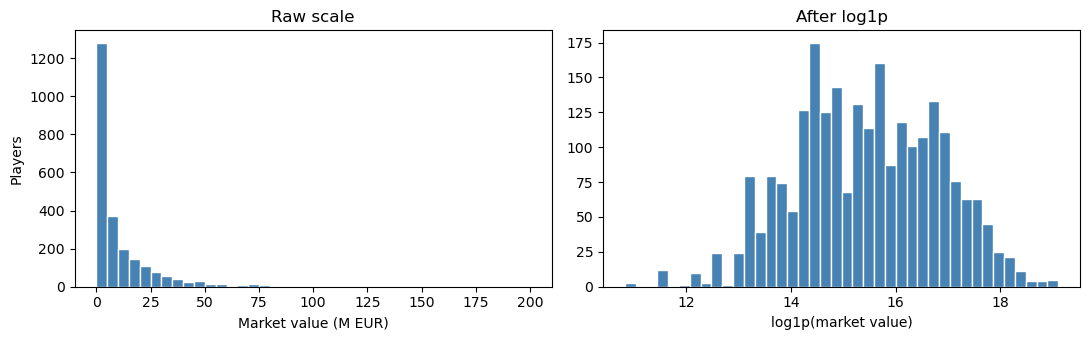

In [3]:
TARGET = "market_value_eur_post_season"

# Left: raw target (millions). Right: log1p transform.
# log1p is log(1 + x), which handles values near zero without exploding.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df[TARGET] / 1e6, bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Market value (M EUR)")
axes[0].set_ylabel("Players")
axes[0].set_title("Raw scale")

axes[1].hist(np.log1p(df[TARGET]), bins=40, color="steelblue", edgecolor="white")
axes[1].set_xlabel("log1p(market value)")
axes[1].set_title("After log1p")
plt.tight_layout()
plt.show()

### Step 3: Train/test split

In [ ]:
# Identifiers are not useful as predictors. club_2024_25 stays as a feature.
drop_cols = [
    "player_id", "name", "transfermarkt_url"
]

X = df.drop(columns=drop_cols + [TARGET])
y = np.log1p(df[TARGET])  # train on log scale, back-transform for reporting

# Hold out 25% for the final test. Same seed = same split every run.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (1815, 12)  X_test: (605, 12)


### Step 4: Preprocessing pipeline

<small>Impute missing values (median for numerics, most-frequent for categoricals), then one-hot encode categoricals. Wrapped in a `Pipeline` so the imputer and encoder only see each CV fold's training portion.</small>

In [15]:
# Trees don't need scaling, but they do need non-NaN inputs.
# Impute missing values inside the Pipeline so that
# the imputer is fit only on the training data of each CV fold preventing data leakage.
numeric_features = [
    "age_at_season_end", "height_in_cm",
    "matches", "minutes",
    "goals", "assists",
    "yellow_cards", "red_cards"
]

categorical_features = [
    "country_of_citizenship",
    "sub_position",
    "foot",
    "league"
]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # handle_unknown="ignore" -> unseen levels at test time become all-zero rows
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features)
    ]
)

### Step 5: Baseline model

<small>As an example, let's start with Random Forest using its default hyperparameters. Report RMSE, MAE, and R<sup>2</sup>, all in euros (original scale), for both train and test. The train vs test gap is the overfit signal.</small>

In [16]:
def report(name, model, X_tr, y_tr, X_te, y_te):
    """All metrics in euros (original scale).
    Train + test reported so the gap can be read as an overfit signal."""
    # Model predicts in log space (y was log1p-transformed). Back-transform to euros.
    pred_tr_eur = np.expm1(model.predict(X_tr))
    pred_te_eur = np.expm1(model.predict(X_te))
    y_tr_eur    = np.expm1(y_tr)
    y_te_eur    = np.expm1(y_te)

    return {
        "model":      name,
        "train_R2":   r2_score(y_tr_eur, pred_tr_eur),
        "test_R2":    r2_score(y_te_eur, pred_te_eur),
        "train_RMSE": np.sqrt(mean_squared_error(y_tr_eur, pred_tr_eur)),
        "test_RMSE":  np.sqrt(mean_squared_error(y_te_eur, pred_te_eur)),
        "train_MAE":  mean_absolute_error(y_tr_eur, pred_tr_eur),
        "test_MAE":   mean_absolute_error(y_te_eur, pred_te_eur)
    }


# Pipeline = preprocessing + model in one object, so CV cannot leak
rf_baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_baseline.fit(X_train, y_train)

# Print the RF defaults used for the baseline; these are the values tuning needs to beat.
defaults = rf_baseline.named_steps["model"].get_params()
print("RF defaults:")
for k in ["n_estimators", "max_depth", "max_features",
          "min_samples_leaf", "min_samples_split", "bootstrap", "criterion"]:
    print(f"  {k}: {defaults[k]}")

baseline_row = report("Baseline (defaults)", rf_baseline, X_train, y_train, X_test, y_test)
pd.DataFrame([baseline_row])

RF defaults:
  n_estimators: 100
  max_depth: None
  max_features: 1.0
  min_samples_leaf: 1
  min_samples_split: 2
  bootstrap: True
  criterion: squared_error


,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Baseline (defaults),0.84734,0.391733,7.621872e+06,1.181496e+07,3.032633e+06,6.149255e+06


In [7]:
# IMPORTANT: 
# Grid Search and Random Search select the hyperparameters that achieve
# the best average cross-validation score based on the chosen scoring metric.

# Common scoring options:
# "r2" (default for regression): proportion of variance explained (higher is better)
# "neg_mean_absolute_error": average prediction error in original units (lower is better)
# "neg_root_mean_squared_error": penalizes large errors more heavily (lower is better)

# Common classification scoring options include:
# "accuracy": proportion of correct predictions
# "precision", "recall", "f1": useful when class imbalance or error types matter
# "roc_auc": evaluates ranking/separation performance across thresholds

# This is achieved by setting the "scoring" argument of GridSearchCV or RandomizedSearchCV to the desired metric string.


### Step 6: Grid Search

<small>Every combination of a small, hand-picked grid. Tuning `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf`.</small>

In [ ]:
# Key Random Forest hyperparameters:
# n_estimators: number of trees (more trees usually improve stability but increase runtime)
# max_depth: maximum tree depth (deeper trees may capture more patterns but overfit)
# max_features: number/fraction of features considered at each split (lower values increase tree diversity)
# min_samples_leaf: minimum samples allowed in a leaf (higher values reduce overfitting)

# 2 x 3 x 2 x 2 = 24 combinations, evaluated with 5-fold CV
param_grid = {
    "model__n_estimators": [200, 500],        # number of trees
    "model__max_depth": [10, 20, None],       # None = unlimited depth
    "model__max_features": [0.5, 2],          # fraction or number of features sampled per split
    "model__min_samples_leaf": [1, 20]       # bigger leaf size = more regularization
}

rf_grid_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

# Shuffle before splitting into folds in case the file has any latent ordering
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=rf_grid_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)

Best params: {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}


### Step 7: Random Search

<small>Sample combinations from broader distributions. Random Search can explore larger spaces efficiently, but it is not guaranteed to outperform Grid Search.</small>

In [ ]:
# Distributions instead of explicit values - sampler draws random "n_iter" combinations
param_dist = {
    "model__n_estimators": randint(200, 501),          # integers from 200 to 500
    "model__max_depth": randint(10, 31),               # integers from 10 to 30
    "model__max_features": uniform(0.3, 0.5),          # fractions from 0.3 to 0.8
    "model__min_samples_leaf": randint(1, 30)         # integers from 1 to 29
}

rf_rand_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

random_search = RandomizedSearchCV(
    estimator=rf_rand_pipe,
    param_distributions=param_dist,
    n_iter=30,             # 30 random configs (vs 24 exhaustive in the grid)
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)

Best params: {'model__max_depth': 18, 'model__max_features': 0.4507141929047883, 'model__min_samples_leaf': 3, 'model__n_estimators': 371}


### Step 8: Final test-set comparison

<small>Final comparison of the three candidates on the held-out test set. The train vs test gap on each metric is the overfit read: large gap (train much better than test) = the model memorized training data (high variance) - both columns equally poor = underfit (high bias) - train and test similar = healthier generalization.</small>

In [ ]:
# Each row: train + test R2, RMSE, MAE (all in euros)
results = pd.DataFrame([
    report("Baseline (defaults)", rf_baseline,                   X_train, y_train, X_test, y_test),
    report("Grid Search",         grid_search.best_estimator_,   X_train, y_train, X_test, y_test),
    report("Random Search"       random_search.best_estimator_, X_train, y_train, X_test, y_test),
])

fmt = {
    "train_R2":   "{:.4f}",
    "test_R2":    "{:.4f}",
    "train_RMSE": "EUR {:,.0f}",
    "test_RMSE":  "EUR {:,.0f}",
    "train_MAE":  "EUR {:,.0f}",
    "test_MAE":   "EUR {:,.0f}"
}
results.style.format(fmt)

,model,train_R2,test_R2,train_RMSE,test_RMSE,train_MAE,test_MAE
0,Baseline (defaults),0.8473,0.3917,"EUR 7,621,872","EUR 11,814,961","EUR 3,032,633","EUR 6,149,255"
1,Grid Search,0.8399,0.3952,"EUR 7,804,402","EUR 11,781,643","EUR 3,130,090","EUR 6,068,190"
2,Random Search,0.6609,0.3905,"EUR 11,358,846","EUR 11,827,154","EUR 4,613,471","EUR 6,070,701"


In [11]:
# Predicting for a single player from the test set
# Here we use the first player in the held-out test dataset as a demonstration.
# In practice, the same workflow can be used to predict market values for new
# unseen player data with the same feature structure.

sample_player = X_test.iloc[[0]]   # features only (used for prediction)

pred_log   = grid_search.best_estimator_.predict(sample_player)
pred_value = np.expm1(pred_log)[0]

print(f"  Predicted market value: EUR {pred_value:,.0f}")

  Predicted market value: EUR 3,011,592


---
## Other Models

<small>Same Pipeline pattern applied to two more model families. Each section: what the hyperparameters mean, a starter search space, then run the search and report train + test metrics.</small>

### Gradient Boosting Models

<small>Two gradient boosting approaches are shown below: sklearn’s built-in Gradient Boosting model and the industry-standard XGBoost library. Both follow the same Pipeline and hyperparameter tuning workflow used earlier.</small>

In [ ]:
# # Gradient Boosting with sklearn
# # Boosting builds trees sequentially, where each new tree focuses on correcting
# # errors made by the previous trees.

# # Key Gradient Boosting hyperparameters:
# # n_estimators: number of boosting stages
# # learning_rate: contribution of each tree
# # max_depth: tree depth (deeper trees may overfit)
# # subsample: fraction of rows used per boosting stage

# from sklearn.ensemble import GradientBoostingRegressor

# gbr_params = {
#     "model__n_estimators": [200, 500],
#     "model__learning_rate": [0.03, 0.1],
#     "model__max_depth": [3, 5],
#     "model__subsample": [0.8, 1.0]
# }

# gbr_pipe = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
# ])

# gbr_search = GridSearchCV(gbr_pipe,
#                           gbr_params,
#                           cv=cv,
#                           scoring="neg_mean_absolute_error",
#                           n_jobs=-1)
# gbr_search.fit(X_train, y_train)

# print("Best params:", gbr_search.best_params_)

# pd.DataFrame([report("Gradient Boosting", gbr_search.best_estimator_,
#                      X_train, y_train, X_test, y_test)])

In [ ]:
# # XGBoost: stronger external boosting package commonly used for tabular data
# # Run the install line once, then comment it out.

# # !pip install xgboost

# # Key XGBoost hyperparameters:
# # n_estimators: number of boosting trees
# # learning_rate: contribution of each tree
# # max_depth: tree depth (deeper trees may overfit)
# # subsample: fraction of rows used per tree
# # colsample_bytree: fraction of features used per tree
# # reg_lambda: L2 regularization strength

# from xgboost import XGBRegressor

# xgb_params = {
#     "model__n_estimators": [200, 500],
#     "model__learning_rate": [0.03, 0.1],
#     "model__max_depth": [3, 5],
#     "model__subsample": [0.8],
#     "model__colsample_bytree": [0.8],
#     "model__reg_lambda": [1, 5]
# }

# xgb_pipe = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"))
# ])

# xgb_search = GridSearchCV(xgb_pipe,
#                           xgb_params,
#                           cv=cv, scoring="neg_mean_absolute_error",
#                           n_jobs=-1)
# xgb_search.fit(X_train, y_train)

# print("Best params:", xgb_search.best_params_)

# pd.DataFrame([report("XGBoost", xgb_search.best_estimator_,
#                      X_train, y_train, X_test, y_test)])

### Neural Network (`MLPRegressor`)

<small>NNs are scale-sensitive, so use `StandardScaler` for numerics. Comment block lists the key HPs; the starter grid below tunes architecture, activation, regularization, and optimization speed.</small>

In [ ]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.neural_network import MLPRegressor

# # Key Neural Network hyperparameters:
# # hidden_layer_sizes: network architecture and complexity
# # activation: nonlinear transformation function
# # alpha: regularization strength (higher values reduce overfitting)
# # learning_rate_init: optimization step size (higher values learn faster but may become unstable)
# # batch_size: number of observations processed at once during training
# # max_iter: maximum number of training iterations

# # Sample search space:
# nn_params = {
#     "model__hidden_layer_sizes": [(32,), (128,), (64, 32), (128, 64)],
#     "model__activation": ["relu"],
#     "model__alpha": [0.001, 0.01],
#     "model__learning_rate_init": [0.001],
#     "model__batch_size": [64]
# }

# # NN needs scaled numerics; rebuild only the numeric branch with StandardScaler.
# nn_preprocessor = ColumnTransformer([
#     ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
#                       ("scale",  StandardScaler())]), numeric_features),
#     ("cat", categorical_pipe, categorical_features)
# ])

# nn_pipe = Pipeline([("preprocess", nn_preprocessor),
#                     ("model", MLPRegressor(random_state=RANDOM_STATE, max_iter=1000, solver="adam"))])

# nn_search = GridSearchCV(nn_pipe,
#                          nn_params,
#                          cv=cv,
#                          scoring="neg_mean_absolute_error",
#                          n_jobs=-1)
# nn_search.fit(X_train, y_train)
# print("Best params:", nn_search.best_params_)
# pd.DataFrame([report("Neural Network", nn_search.best_estimator_,
#                      X_train, y_train, X_test, y_test)])